## self-sustained activity in a recurrent neural network using numpy

Here's a Python implementation of a recurrent network of 100 LIF neurons with random delays and sustained activity using Brian2:


Created 2027 recurrent connections
Running simulation...
Progress: 0.0%
Progress: 10.0%
Progress: 20.0%
Progress: 30.0%
Progress: 40.0%
Progress: 50.0%
Progress: 60.0%
Progress: 70.0%
Progress: 80.0%
Progress: 90.0%
Simulation completed!


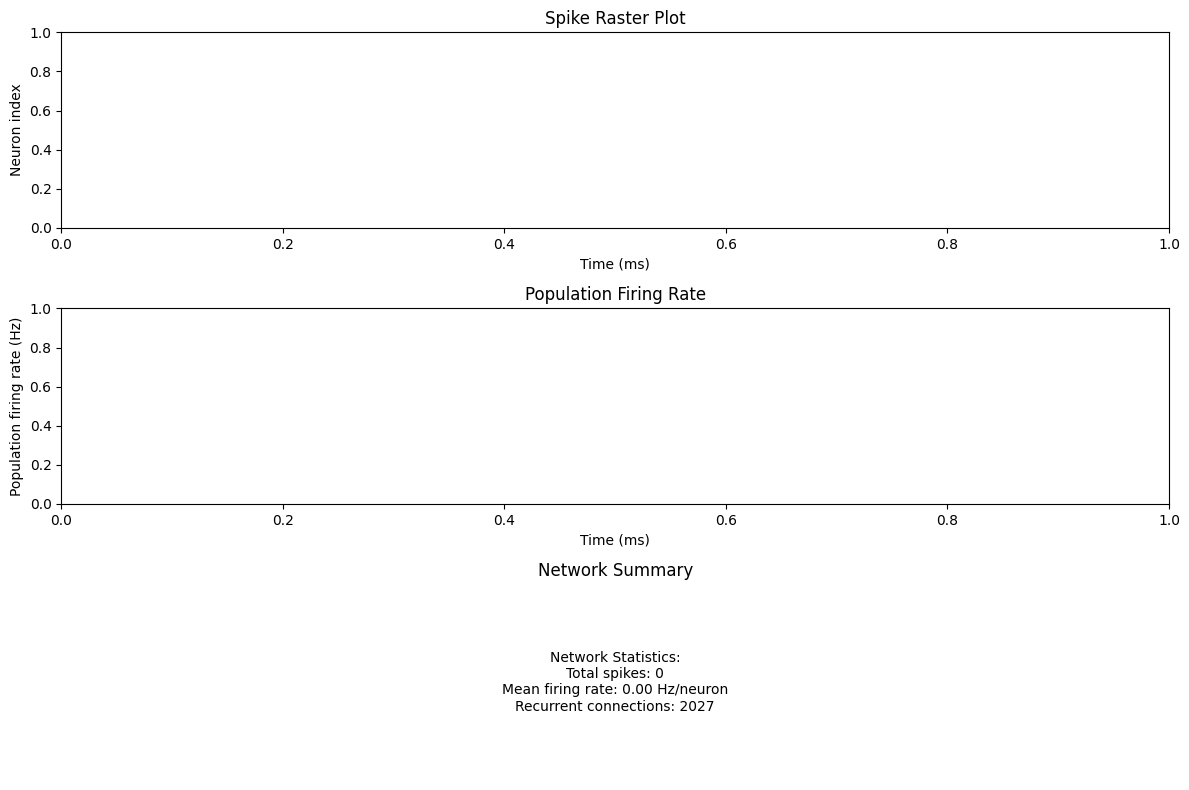


Network Statistics:
Total spikes: 0
Mean firing rate: 0.00 Hz/neuron
Recurrent connections: 2027
Connection density: 20.3%


In [1]:
import numpy as np
import matplotlib.pyplot as plt

class LIFNetwork:
    def __init__(self, N=100):
        self.N = N  # Number of neurons
        
        # Neuron parameters (in ms, mV, nA units)
        self.tau_m = 20.0      # Membrane time constant
        self.V_rest = -70.0    # Resting potential
        self.V_th = -50.0      # Spike threshold
        self.V_reset = -65.0   # Reset potential
        self.R_m = 100.0       # Membrane resistance (Mohm)
        self.tau_ref = 2.0     # Refractory period (ms)
        
        # Simulation parameters
        self.dt = 0.1          # Time step (ms)
        self.delay_min = 2.0   # Minimum synaptic delay (ms)
        self.delay_max = 40.0  # Maximum synaptic delay (ms)
        
        # Initialize neuron states
        self.v = np.full(N, self.V_rest)  # Membrane potentials
        self.last_spike = np.full(N, -1000.0)  # Last spike times
        self.in_refractory = np.zeros(N, dtype=bool)  # Refractory state
        
        # Create recurrent connections
        self.connections = self._create_connections()
        
        # Spike buffer for delayed transmission
        self.spike_buffer = {}  # time -> list of (pre_neuron, weight)
        
        # Recording
        self.spike_times = [[] for _ in range(N)]
        
    def _create_connections(self):
        """Create sparse recurrent connections with random delays"""
        connections = []
        sparsity = 0.2  # 20% connectivity
        
        for pre in range(self.N):
            for post in range(self.N):
                if np.random.rand() < sparsity:
                    # Random delay between 2-40 ms
                    delay = np.random.uniform(self.delay_min, self.delay_max)
                    # Random synaptic weight (exponential distribution)
                    weight = 0.5 * np.random.exponential(1.0)
                    connections.append((pre, post, delay, weight))
        
        print(f"Created {len(connections)} recurrent connections")
        return connections
    
    def _deliver_spikes(self, t):
        """Deliver spikes that have reached their target time"""
        if t in self.spike_buffer:
            for pre_neuron, weight in self.spike_buffer[t]:
                self.v[pre_neuron] += weight  # Apply synaptic input
            del self.spike_buffer[t]
    
    def _update_neurons(self, t, external_input=None):
        """Update neuron states for one time step"""
        # Apply external input if provided
        if external_input is not None:
            self.v[external_input] += 1.0  # Simple input current
            
        # Update membrane potentials
        for i in range(self.N):
            # Check if neuron is in refractory period
            if t - self.last_spike[i] <= self.tau_ref:
                self.in_refractory[i] = True
            else:
                self.in_refractory[i] = False
                
            # Update membrane potential if not in refractory period
            if not self.in_refractory[i]:
                # Leaky integration: dv/dt = (-(v - V_rest) + R_m*I)/tau_m
                dv = (-(self.v[i] - self.V_rest)) / self.tau_m * self.dt
                self.v[i] += dv
                
                # Check for spike
                if self.v[i] >= self.V_th:
                    # Record spike
                    self.spike_times[i].append(t)
                    self.last_spike[i] = t
                    
                    # Reset voltage
                    self.v[i] = self.V_reset
                    
                    # Schedule synaptic outputs with delays
                    for pre, post, delay, weight in self.connections:
                        if pre == i:  # This neuron spiked
                            delivery_time = t + delay
                            delivery_time = round(delivery_time / self.dt) * self.dt  # Quantize
                            
                            if delivery_time not in self.spike_buffer:
                                self.spike_buffer[delivery_time] = []
                            self.spike_buffer[delivery_time].append((post, weight))
    
    def simulate(self, duration=500.0, stim_duration=50.0):
        """Run simulation"""
        steps = int(duration / self.dt)
        
        # Generate Poisson input times for stimulation period
        poisson_times = {}
        if stim_duration > 0:
            # Average 50 Hz over 20 neurons for 50ms
            avg_spikes = 50 * stim_duration / 1000 * 20  # total expected spikes
            num_spikes = np.random.poisson(avg_spikes)
            
            # Distribute spikes randomly in time and across neurons
            spike_times = np.random.uniform(0, stim_duration, num_spikes)
            spike_neurons = np.random.randint(0, self.N, num_spikes)
            
            for time, neuron in zip(spike_times, spike_neurons):
                time_step = int(time / self.dt)
                if time_step not in poisson_times:
                    poisson_times[time_step] = []
                poisson_times[time_step].append(neuron)
        
        print("Running simulation...")
        for step in range(steps):
            current_time = step * self.dt
            
            # Deliver external input
            external_neurons = poisson_times.get(step, None)
            
            # Deliver delayed spikes
            self._deliver_spikes(current_time)
            
            # Update neuron states
            self._update_neurons(current_time, external_neurons)
            
            # Progress indicator
            if step % (steps // 10) == 0:
                print(f"Progress: {step/steps*100:.1f}%")
        
        print("Simulation completed!")
    
    def plot_results(self):
        """Plot spike raster and firing rate"""
        plt.figure(figsize=(12, 8))
        
        # Raster plot
        plt.subplot(3, 1, 1)
        for i in range(self.N):
            if len(self.spike_times[i]) > 0:
                times = self.spike_times[i]
                plt.plot(times, [i]*len(times), '.k', markersize=1)
        plt.xlabel('Time (ms)')
        plt.ylabel('Neuron index')
        plt.title('Spike Raster Plot')
        
        # Collect all spike times for population analysis
        all_spike_times = []
        for neuron_spikes in self.spike_times:
            all_spike_times.extend(neuron_spikes)
        
        # Population firing rate
        plt.subplot(3, 1, 2)
        if len(all_spike_times) > 0:
            bin_size = 10.0  # ms
            bins = np.arange(0, max(all_spike_times) + bin_size, bin_size)
            histogram, _ = np.histogram(all_spike_times, bins=bins)
            firing_rate = histogram / bin_size * 1000 / self.N  # Hz/neuron
            plt.plot(bins[:-1], firing_rate, 'b-', linewidth=1)
        plt.xlabel('Time (ms)')
        plt.ylabel('Population firing rate (Hz)')
        plt.title('Population Firing Rate')
        
        # Membrane potential trace of sample neuron
        plt.subplot(3, 1, 3)
        # For simplicity, we'll just show some statistics
        plt.text(0.5, 0.5, f'Network Statistics:\n'
                          f'Total spikes: {sum(len(spikes) for spikes in self.spike_times)}\n'
                          f'Mean firing rate: {sum(len(spikes) for spikes in self.spike_times)/(self.N * 0.5):.2f} Hz/neuron\n'
                          f'Recurrent connections: {len(self.connections)}',
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.axis('off')
        plt.title('Network Summary')
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        total_spikes = sum(len(spikes) for spikes in self.spike_times)
        mean_rate = total_spikes / (self.N * 0.5)  # 0.5 seconds duration
        print(f"\nNetwork Statistics:")
        print(f"Total spikes: {total_spikes}")
        print(f"Mean firing rate: {mean_rate:.2f} Hz/neuron")
        print(f"Recurrent connections: {len(self.connections)}")
        print(f"Connection density: {len(self.connections)/(self.N**2)*100:.1f}%")

# Run the network
if __name__ == "__main__":
    # Create and run network
    network = LIFNetwork(N=100)
    network.simulate(duration=500.0, stim_duration=50.0)
    network.plot_results()